# Working with full dataset

In [3]:
# ── 1. Setup ──────────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

import os
import random
import platform
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, balanced_accuracy_score, f1_score
)

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input, LSTM, Bidirectional, Dense, Dropout,
    LayerNormalization, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

SEED = 42


np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_ROOT = Path('Single Activity')

DATA_SOURCES = ['3D data', 'New_samples']

# Ignore this folder for supervised 4-class activity classification
IGNORE_DIRS = ['Random']

# Activity labels
ACTIVITIES = ['Sitting', 'Standing', 'Waving', 'Walking']

TRAIN_DISTS = ['1m', '2m', '3m']
TEST_DISTS  = ['4m', '5m']
ALL_DISTS   = TRAIN_DISTS + TEST_DISTS

COLUMN_MAP = {
    'azimuth_deg': 'azimuth',
    'elevation_deg': 'elevation'
}

# ── Sequence hyperparameters ──────────────────────────────────────────────────
WINDOW_SIZE = 30
STRIDE = 5
NUM_CLASSES = len(ACTIVITIES)

# ── Display setup information ─────────────────────────────────────────────────
print(f'Python       : {platform.python_version()}')
print(f'TensorFlow   : {tf.__version__}')
print(f'Data root    : {DATA_ROOT}')
print(f'Data sources : {DATA_SOURCES}')
print(f'Activities   : {ACTIVITIES}')
print(f'Train dists  : {TRAIN_DISTS}')
print(f'Test dists   : {TEST_DISTS}')
print(f'Window size  : {WINDOW_SIZE} frames')
print(f'Stride       : {STRIDE}')
print(f'Num classes  : {NUM_CLASSES}')



Python       : 3.10.0
TensorFlow   : 2.19.0
Data root    : Single Activity
Data sources : ['3D data', 'New_samples']
Activities   : ['Sitting', 'Standing', 'Waving', 'Walking']
Train dists  : ['1m', '2m', '3m']
Test dists   : ['4m', '5m']
Window size  : 30 frames
Stride       : 5
Num classes  : 4


In [4]:
# ── 2. Load Raw Point-Level Data ──────────────────────────────────────────────

def normalize_dist_name(dist_name):
    """
    Convert both '1 m' and '1m' into '1m'.
    """
    return str(dist_name).replace(' ', '').lower()


def find_distance_folder(source, act, target_dist):
    """
    Find the actual distance folder for one source/activity.

    Handles:
        3D data      -> '1 m', '2 m', ...
        New_samples  -> '1m', '2m', ...
    """
    act_path = DATA_ROOT / source / act

    if not act_path.exists():
        print(f'[Missing activity folder] {act_path}')
        return None

    target_norm = normalize_dist_name(target_dist)

    for folder in sorted(act_path.iterdir()):
        if folder.is_dir() and folder.name not in IGNORE_DIRS:
            if normalize_dist_name(folder.name) == target_norm:
                return folder

    print(f'[Missing distance folder] source={source}, activity={act}, distance={target_dist}')
    return None


def load_point_level_data(distances):
    """
    Load all PointCloud_snr.csv files from DATA_SOURCES.

    Output:
        points_df: one row = one detected radar point.
    """
    all_points = []

    for source in DATA_SOURCES:
        for act in ACTIVITIES:
            for dist in distances:

                dist_path = find_distance_folder(source, act, dist)

                if dist_path is None:
                    continue

                csv_files = sorted(dist_path.rglob('PointCloud_snr.csv'))

                if len(csv_files) == 0:
                    print(f'[No CSV found] {dist_path}')
                    continue

                for csv_path in csv_files:

                    df = pd.read_csv(csv_path)
                    df.columns = df.columns.str.strip()
                    df = df.rename(columns=COLUMN_MAP)

                    required_cols = [
                        'timestamp_s', 'frame_number', 'point_index',
                        'x', 'y', 'z', 'doppler', 'range',
                        'azimuth', 'elevation', 'snr', 'noise'
                    ]

                    missing_cols = [c for c in required_cols if c not in df.columns]

                    if missing_cols:
                        raise ValueError(f'Missing columns in {csv_path}: {missing_cols}')

                    # Direct file in distance folder = original sample from 3D data.
                    # File inside left/middle/right/right_1/etc. = sample folder name.
                    if csv_path.parent == dist_path:
                        sample = 'original'
                    else:
                        sample = csv_path.parent.name

                    df['source'] = source
                    df['activity'] = act
                    df['distance'] = normalize_dist_name(dist)
                    df['sample'] = sample
                    df['source_file'] = str(csv_path)

                    df['session_id'] = (
                        source.replace(' ', '_') + '_' +
                        act + '_' +
                        normalize_dist_name(dist) + '_' +
                        sample
                    )

                    all_points.append(df)

    if len(all_points) == 0:
        raise ValueError('No PointCloud_snr.csv files found. Check DATA_ROOT and folder structure.')

    return pd.concat(all_points, ignore_index=True)


print('Loading training point-level data  (1m, 2m, 3m)...')
train_points = load_point_level_data(TRAIN_DISTS)

print(f'  train_points: {train_points.shape}')
print(f'  detected points by activity: {train_points["activity"].value_counts().to_dict()}')


print('\nLoading test point-level data      (4m, 5m)...')
test_points = load_point_level_data(TEST_DISTS)

print(f'  test_points : {test_points.shape}')
print(f'  detected points by activity: {test_points["activity"].value_counts().to_dict()}')


Loading training point-level data  (1m, 2m, 3m)...
  train_points: (20830, 18)
  detected points by activity: {'Walking': 6021, 'Sitting': 5099, 'Standing': 4959, 'Waving': 4751}

Loading test point-level data      (4m, 5m)...
  test_points : (11732, 18)
  detected points by activity: {'Walking': 3940, 'Sitting': 2780, 'Standing': 2779, 'Waving': 2233}


In [5]:
# ── 3. Create Frame-Level Features — Improved Feature Set V2 ─────────────────

FEATURE_COLS = [
    # Point density
    'point_count',

    # Spatial posture / spread
    'mean_x', 'std_x',
    'std_y',
    'mean_z', 'std_z',
    'min_z', 'max_z', 'z_range', 'z_iqr',

    # Doppler / motion
    'mean_doppler', 'std_doppler',
    'min_doppler', 'max_doppler',
    'abs_doppler', 'max_abs_doppler',
    'doppler_range',
    'moving_point_ratio',
    'weak_motion_ratio',

    # Range spread
    'std_range',

    # Angular features
    'mean_azimuth', 'std_azimuth',
    'azimuth_range', 'azimuth_iqr',
    'mean_elevation', 'std_elevation',
    'elevation_range', 'elevation_iqr',

    # Signal quality — important for 4m/5m stability
    'mean_snr',
    'mean_noise',
    'snr_noise_gap'
]

N_FEATURES = len(FEATURE_COLS)
print(f'Features ({N_FEATURES}):')
print(FEATURE_COLS)


def make_frame_features(points_df):

    def agg(g):
        z_q25 = g['z'].quantile(0.25)
        z_q75 = g['z'].quantile(0.75)

        az_q25 = g['azimuth'].quantile(0.25)
        az_q75 = g['azimuth'].quantile(0.75)

        el_q25 = g['elevation'].quantile(0.25)
        el_q75 = g['elevation'].quantile(0.75)

        moving_threshold = 0.02
        weak_threshold = 0.01

        mean_snr = g['snr'].mean()
        mean_noise = g['noise'].mean()

        return pd.Series({
            # Point density
            'point_count': len(g),

            # Spatial posture / spread
            'mean_x': g['x'].mean(),
            'std_x': g['x'].std(ddof=0),
            'std_y': g['y'].std(ddof=0),

            'mean_z': g['z'].mean(),
            'std_z': g['z'].std(ddof=0),
            'min_z': g['z'].min(),
            'max_z': g['z'].max(),
            'z_range': g['z'].max() - g['z'].min(),
            'z_iqr': z_q75 - z_q25,

            # Doppler / motion
            'mean_doppler': g['doppler'].mean(),
            'std_doppler': g['doppler'].std(ddof=0),
            'min_doppler': g['doppler'].min(),
            'max_doppler': g['doppler'].max(),
            'abs_doppler': g['doppler'].abs().mean(),
            'max_abs_doppler': g['doppler'].abs().max(),
            'doppler_range': g['doppler'].max() - g['doppler'].min(),

            'moving_point_ratio': (g['doppler'].abs() > moving_threshold).mean(),
            'weak_motion_ratio': (g['doppler'].abs() > weak_threshold).mean(),

            # Range spread
            'std_range': g['range'].std(ddof=0),

            # Angular features
            'mean_azimuth': g['azimuth'].mean(),
            'std_azimuth': g['azimuth'].std(ddof=0),
            'azimuth_range': g['azimuth'].max() - g['azimuth'].min(),
            'azimuth_iqr': az_q75 - az_q25,

            'mean_elevation': g['elevation'].mean(),
            'std_elevation': g['elevation'].std(ddof=0),
            'elevation_range': g['elevation'].max() - g['elevation'].min(),
            'elevation_iqr': el_q75 - el_q25,

            # Signal quality
            'mean_snr': mean_snr,
            'mean_noise': mean_noise,
            'snr_noise_gap': mean_snr - mean_noise,
        })

    feat_df = (
        points_df
        .groupby(
            ['source', 'activity', 'distance', 'sample', 'session_id', 'frame_number'],
            sort=True
        )
        .apply(agg)
        .reset_index()
        .fillna(0)
    )

    return feat_df


print('Creating training frame-level features...')
train_feat = make_frame_features(train_points)

print('Creating test frame-level features...')
test_feat = make_frame_features(test_points)

print('\nTrain frame features:', train_feat.shape)
print('Test frame features :', test_feat.shape)

print('\nTrain frames by activity:')
print(train_feat['activity'].value_counts().to_dict())

print('\nTest frames by activity:')
print(test_feat['activity'].value_counts().to_dict())

Features (31):
['point_count', 'mean_x', 'std_x', 'std_y', 'mean_z', 'std_z', 'min_z', 'max_z', 'z_range', 'z_iqr', 'mean_doppler', 'std_doppler', 'min_doppler', 'max_doppler', 'abs_doppler', 'max_abs_doppler', 'doppler_range', 'moving_point_ratio', 'weak_motion_ratio', 'std_range', 'mean_azimuth', 'std_azimuth', 'azimuth_range', 'azimuth_iqr', 'mean_elevation', 'std_elevation', 'elevation_range', 'elevation_iqr', 'mean_snr', 'mean_noise', 'snr_noise_gap']
Creating training frame-level features...
Creating test frame-level features...

Train frame features: (4742, 37)
Test frame features : (3144, 37)

Train frames by activity:
{'Standing': 1386, 'Sitting': 1378, 'Waving': 1007, 'Walking': 971}

Test frames by activity:
{'Sitting': 920, 'Standing': 916, 'Walking': 665, 'Waving': 643}


In [6]:
# ── 4. Create Sliding-Window Sequences ────────────────────────────────────────

def build_windows(feat_df, window_size=WINDOW_SIZE, stride=STRIDE):
    X, y, d, sessions = [], [], [], []

    group_cols = ['source', 'activity', 'distance', 'sample', 'session_id']

    for (_, act, dist, _, session_id), g in feat_df.groupby(group_cols, sort=False):
        g = g.sort_values('frame_number').reset_index(drop=True)
        values = g[FEATURE_COLS].values.astype(np.float32)

        if len(values) < window_size:
            continue

        for start in range(0, len(values) - window_size + 1, stride):
            X.append(values[start:start + window_size])
            y.append(act)
            d.append(dist)
            sessions.append(session_id)

    return (
        np.array(X, dtype=np.float32),
        np.array(y),
        np.array(d),
        np.array(sessions)
    )


X_train_raw, y_train_str, d_train, train_sessions = build_windows(train_feat)
X_test_raw, y_test_str, d_test, test_sessions = build_windows(test_feat)

print(f'X_train_raw: {X_train_raw.shape}')
print(f'X_test_raw : {X_test_raw.shape}')

print('\nTrain windows by activity:')
print(pd.Series(y_train_str).value_counts().to_dict())

print('\nTest windows by activity:')
print(pd.Series(y_test_str).value_counts().to_dict())

print('\nTrain windows by distance:')
print(pd.Series(d_train).value_counts().sort_index().to_dict())

print('\nTest windows by distance:')
print(pd.Series(d_test).value_counts().sort_index().to_dict())

print('\nTrain sessions:', len(np.unique(train_sessions)))
print('Test sessions :', len(np.unique(test_sessions)))

X_train_raw: (690, 30, 31)
X_test_raw : (454, 30, 31)

Train windows by activity:
{'Sitting': 212, 'Standing': 212, 'Waving': 136, 'Walking': 130}

Test windows by activity:
{'Sitting': 140, 'Standing': 140, 'Walking': 89, 'Waving': 85}

Train windows by distance:
{'1m': 235, '2m': 238, '3m': 217}

Test windows by distance:
{'4m': 220, '5m': 234}

Train sessions: 48
Test sessions : 32


X_train: (690, 30, 31)  y_train: (690, 4)
X_test : (454, 30, 31)   y_test : (454, 4)
Classes: ['Sitting', 'Standing', 'Walking', 'Waving']


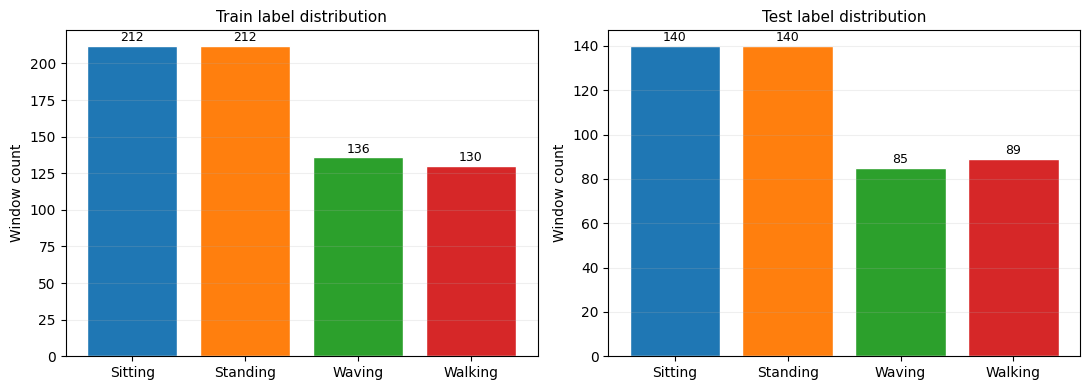

In [7]:
# ── 5. Normalise Features and Encode Labels ───────────────────────────────────

N_train, T, F = X_train_raw.shape
N_test = X_test_raw.shape[0]

scaler = StandardScaler()

X_train_2d = X_train_raw.reshape(-1, F)
X_test_2d  = X_test_raw.reshape(-1, F)

scaler.fit(X_train_2d)

X_train = scaler.transform(X_train_2d).reshape(N_train, T, F).astype(np.float32)
X_test  = scaler.transform(X_test_2d).reshape(N_test, T, F).astype(np.float32)

le = LabelEncoder()
le.fit(ACTIVITIES)

y_train_idx = le.transform(y_train_str)
y_test_idx  = le.transform(y_test_str)

y_train_oh = to_categorical(y_train_idx, num_classes=NUM_CLASSES)
y_test_oh  = to_categorical(y_test_idx, num_classes=NUM_CLASSES)

print(f'X_train: {X_train.shape}  y_train: {y_train_oh.shape}')
print(f'X_test : {X_test.shape}   y_test : {y_test_oh.shape}')
print(f'Classes: {list(le.classes_)}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

plot_order = pd.Series(y_train_str).value_counts().index.tolist()
colors = sns.color_palette('tab10', NUM_CLASSES)

for ax, labels, title in zip(
    axes,
    [y_train_str, y_test_str],
    ['Train label distribution', 'Test label distribution']
):
    counts = pd.Series(labels).value_counts().reindex(plot_order, fill_value=0)

    bars = ax.bar(
        counts.index,
        counts.values,
        color=colors,
        edgecolor='white'
    )

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Window count')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(True, alpha=0.2, axis='y')

    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 1,
            str(int(h)),
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.savefig('new_lstm_label_dist.png', dpi=120, bbox_inches='tight')
plt.show()

In [8]:
# ── 6. Build BiLSTM + Attention Model ────────────────────────────────────────

from tensorflow.keras.layers import (
    Input, LSTM, Bidirectional, Dense, Dropout,
    LayerNormalization, BatchNormalization
)
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Layer

tf.keras.backend.clear_session()

class AttentionPooling(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.score_dense = Dense(1)

    def call(self, inputs):
        scores = self.score_dense(inputs)          # B x T x 1
        weights = tf.nn.softmax(scores, axis=1)    # B x T x 1
        return tf.reduce_sum(inputs * weights, axis=1)


def build_bilstm_attention_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)
    )(inputs)
    x = LayerNormalization()(x)
    x = Dropout(0.20)(x)

    x = Bidirectional(
        LSTM(
            64,
            return_sequences=True,
            dropout=0.10,
            kernel_regularizer=regularizers.l2(1e-4)
        )
    )(x)
    x = LayerNormalization()(x)
    x = Dropout(0.30)(x)

    x = Bidirectional(
        LSTM(
            32,
            return_sequences=True,
            dropout=0.10,
            kernel_regularizer=regularizers.l2(1e-4)
        )
    )(x)

    x = AttentionPooling()(x)
    x = LayerNormalization()(x)

    x = Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = BatchNormalization()(x)
    x = Dropout(0.35)(x)

    x = Dense(
        32,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = Dropout(0.25)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=7e-4,
            clipnorm=1.0
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


model = build_bilstm_attention_model(
    input_shape=(WINDOW_SIZE, N_FEATURES),
    num_classes=NUM_CLASSES
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 31)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30, 64)         │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 30, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 30, 128)        │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 30, 64)         │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_pooling               │ (None, 64)             │            65 │
│ (AttentionPooling)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 64)             │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,517 (455.14 KB)

 Trainable params: 116,389 (454.64 KB)

 Non-trainable params: 128 (512.00 B)

In [12]:
# ── 7. Train Model with Stratified Validation Split + Targeted Class Weights ──

from sklearn.model_selection import train_test_split

EPOCHS = 100
BATCH_SIZE = 16
VAL_SPLIT = 0.15

train_idx, val_idx = train_test_split(
    np.arange(len(X_train)),
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=y_train_idx
)

X_tr, X_val = X_train[train_idx], X_train[val_idx]
y_tr, y_val = y_train_oh[train_idx], y_train_oh[val_idx]

class_weight_dict = {
    le.transform(['Sitting'])[0]: 0.65,
    le.transform(['Standing'])[0]: 1.80,
    le.transform(['Walking'])[0]: 1.00,
    le.transform(['Waving'])[0]: 1.45
}

print('Training subset:', X_tr.shape)
print('Validation subset:', X_val.shape)

print('\nTraining labels:')
print(pd.Series(y_train_str[train_idx]).value_counts().to_dict())

print('\nValidation labels:')
print(pd.Series(y_train_str[val_idx]).value_counts().to_dict())

print('\nClass weights:')
for i, cls in enumerate(le.classes_):
    print(f'{cls:8s}: {class_weight_dict[i]:.2f}')

os.makedirs('checkpoints', exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=18,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'checkpoints/best_model_targeted_weighted.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=0
    )
]

history = model.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print(f'\nTraining stopped at epoch {len(history.history["loss"])}')

Training subset: (586, 30, 31)
Validation subset: (104, 30, 31)

Training labels:
{'Sitting': 180, 'Standing': 180, 'Waving': 116, 'Walking': 110}

Validation labels:
{'Sitting': 32, 'Standing': 32, 'Walking': 20, 'Waving': 20}

Class weights:
Sitting : 0.65
Standing: 1.80
Walking : 1.00
Waving  : 1.45
Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7487 - loss: 1.0078 - val_accuracy: 0.7885 - val_loss: 0.5469 - learning_rate: 8.7500e-05
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7661 - loss: 0.8815 - val_accuracy: 0.7596 - val_loss: 0.5432 - learning_rate: 8.7500e-05
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7392 - loss: 0.7755 - val_accuracy: 0.7885 - val_loss: 0.5177 - learning_rate: 8.7500e-05
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7593 - loss: 0.7311 - val_accuracy: 0.7788 - val_loss: 0.5035 - learning_rate: 8.7500e-05
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7379 -

In [13]:
# ── 8. Overall Evaluation on Test Set (4 m + 5 m) ─────────────────────────────

test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)

print('Overall Evaluation on Test Set (4 m + 5 m)')
print(f'Test loss    : {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

y_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = y_test_idx

bal_acc = balanced_accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')

print(f'Balanced accuracy: {bal_acc:.4f}')
print(f'Macro F1-score   : {macro_f1:.4f}')

print('\nClassification report:')
print(
    classification_report(
        y_true,
        y_pred,
        target_names=le.classes_,
        zero_division=0
    )
)

Overall Evaluation on Test Set (4 m + 5 m)
Test loss    : 0.8898
Test accuracy: 0.7026
Balanced accuracy: 0.7141
Macro F1-score   : 0.7321

Classification report:
              precision    recall  f1-score   support

     Sitting       0.58      0.69      0.63       140
    Standing       0.58      0.62      0.60       140
     Walking       1.00      0.98      0.99        89
      Waving       0.94      0.56      0.71        85

    accuracy                           0.70       454
   macro avg       0.78      0.71      0.73       454
weighted avg       0.73      0.70      0.71       454



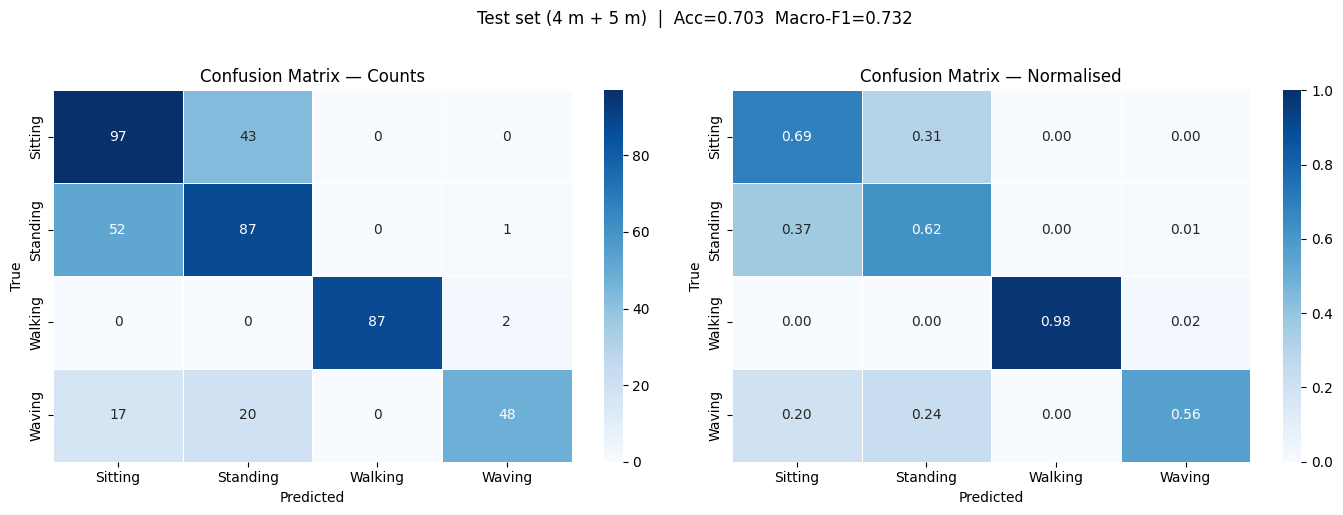

In [14]:
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[0], linewidths=0.4)
axes[0].set_title('Confusion Matrix — Counts', fontsize=12)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            vmin=0, vmax=1, ax=axes[1], linewidths=0.4)
axes[1].set_title('Confusion Matrix — Normalised', fontsize=12)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.suptitle(f'Test set (4 m + 5 m)  |  Acc={test_acc:.3f}  Macro-F1={macro_f1:.3f}',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('new_lstm_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

In [15]:
print('=' * 55)
print('Per-Distance Performance on Test Set')
print('=' * 55)

dist_metrics = []
for dist in TEST_DISTS:
    mask  = d_test == dist
    if mask.sum() == 0:
        continue
    yt_d  = y_true[mask]
    yp_d  = y_pred[mask]
    acc_d = accuracy_score(yt_d, yp_d)
    f1_d  = f1_score(yt_d, yp_d, average='macro', zero_division=0)
    bal_d = balanced_accuracy_score(yt_d, yp_d)
    dist_metrics.append({'Distance': dist, 'Samples': int(mask.sum()),
                          'Accuracy': round(acc_d, 4),
                          'Balanced Acc': round(bal_d, 4),
                          'Macro F1': round(f1_d, 4)})
    print(f'\n  Distance: {dist}  ({mask.sum()} windows)')
    print(f'  Accuracy={acc_d:.4f}  BalAcc={bal_d:.4f}  MacroF1={f1_d:.4f}')
    print(classification_report(yt_d, yp_d, target_names=le.classes_,
                                  zero_division=0, digits=3))

dist_df = pd.DataFrame(dist_metrics)
print(dist_df.to_string(index=False))

Per-Distance Performance on Test Set

  Distance: 4m  (220 windows)
  Accuracy=0.8091  BalAcc=0.8393  MacroF1=0.8410
              precision    recall  f1-score   support

     Sitting      0.690     0.721     0.705        68
    Standing      0.708     0.687     0.697        67
     Walking      1.000     1.000     1.000        45
      Waving      0.974     0.950     0.962        40

    accuracy                          0.809       220
   macro avg      0.843     0.839     0.841       220
weighted avg      0.811     0.809     0.810       220


  Distance: 5m  (234 windows)
  Accuracy=0.6026  BalAcc=0.6013  MacroF1=0.6054
              precision    recall  f1-score   support

     Sitting      0.505     0.667     0.575        72
    Standing      0.482     0.562     0.519        73
     Walking      1.000     0.955     0.977        44
      Waving      0.833     0.222     0.351        45

    accuracy                          0.603       234
   macro avg      0.705     0.601     0.60

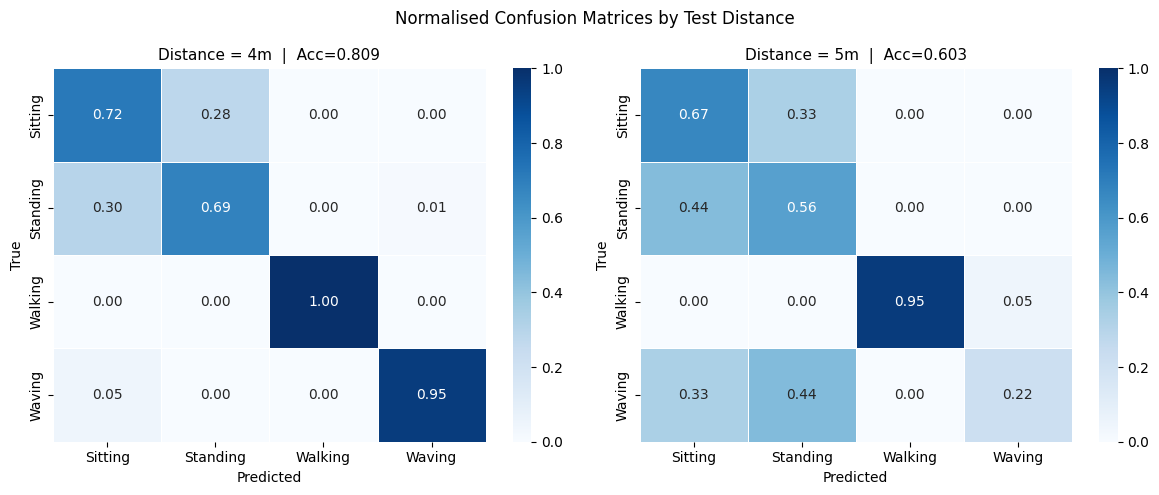

In [16]:
# Per-distance confusion matrices
fig, axes = plt.subplots(1, len(TEST_DISTS), figsize=(6 * len(TEST_DISTS), 5))
if len(TEST_DISTS) == 1:
    axes = [axes]

for ax, dist in zip(axes, TEST_DISTS):
    mask = d_test == dist
    if mask.sum() == 0:
        ax.set_visible(False)
        continue
    cm_d      = confusion_matrix(y_true[mask], y_pred[mask])
    cm_d_norm = cm_d.astype(float) / cm_d.sum(axis=1, keepdims=True)
    sns.heatmap(cm_d_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                vmin=0, vmax=1, ax=ax, linewidths=0.4)
    acc_d = accuracy_score(y_true[mask], y_pred[mask])
    ax.set_title(f'Distance = {dist}  |  Acc={acc_d:.3f}', fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle('Normalised Confusion Matrices by Test Distance', fontsize=12)
plt.tight_layout()
plt.savefig('new_lstm_cm_per_distance.png', dpi=120, bbox_inches='tight')
plt.show()

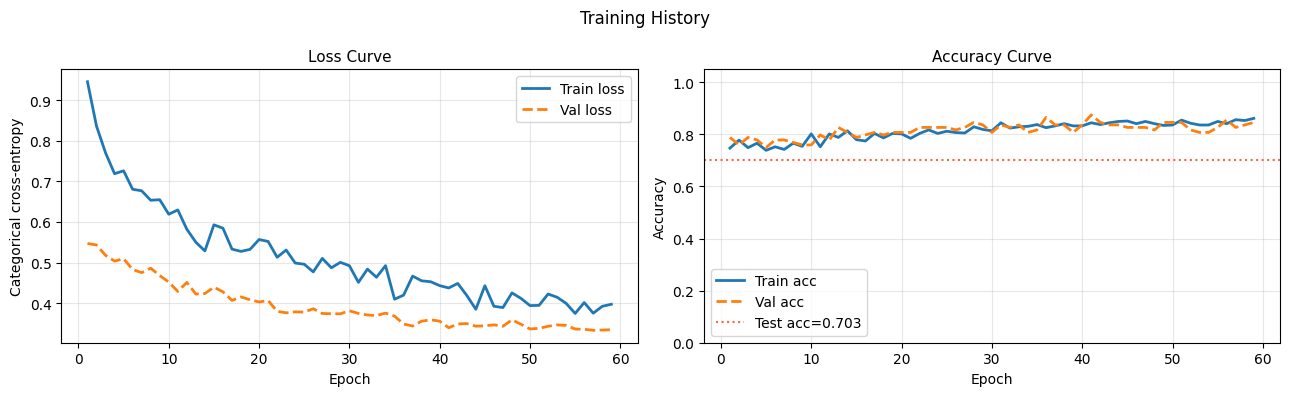

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs_ran = range(1, len(history.history['loss']) + 1)

axes[0].plot(epochs_ran, history.history['loss'],     label='Train loss',  linewidth=2)
axes[0].plot(epochs_ran, history.history['val_loss'], label='Val loss',    linewidth=2, linestyle='--')
axes[0].set_title('Loss Curve', fontsize=11)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Categorical cross-entropy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history.history['accuracy'],     label='Train acc',  linewidth=2)
axes[1].plot(epochs_ran, history.history['val_accuracy'], label='Val acc',    linewidth=2, linestyle='--')
axes[1].axhline(test_acc, color='tomato', linewidth=1.5, linestyle=':',
                label=f'Test acc={test_acc:.3f}')
axes[1].set_title('Accuracy Curve', fontsize=11)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=12)
plt.tight_layout()
plt.savefig('new_lstm_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()

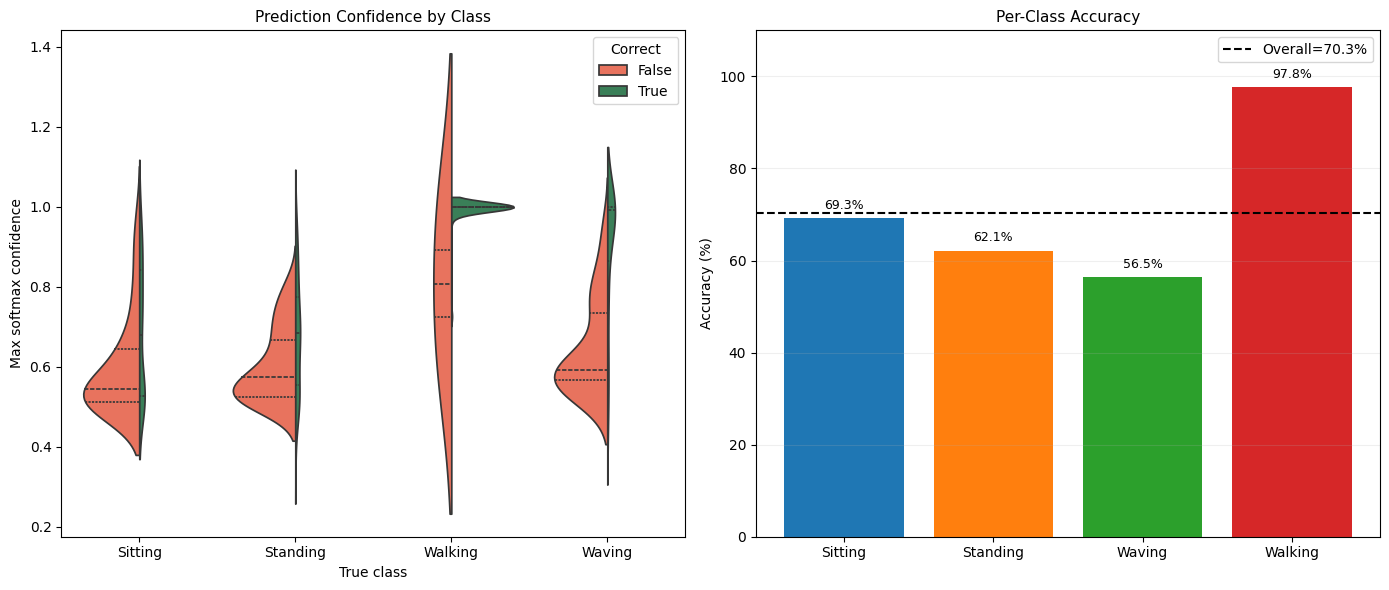

In [18]:
# Per-class confidence distribution
conf_df = pd.DataFrame({
    'true_label': [le.classes_[i] for i in y_true],
    'pred_label': [le.classes_[i] for i in y_pred],
    'confidence': y_prob.max(axis=1),
    'correct':    y_true == y_pred,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(data=conf_df, x='true_label', y='confidence',
               hue='correct', split=True, inner='quartile',
               palette={True: 'seagreen', False: 'tomato'}, ax=axes[0])
axes[0].set_title('Prediction Confidence by Class', fontsize=11)
axes[0].set_xlabel('True class'); axes[0].set_ylabel('Max softmax confidence')
axes[0].legend(title='Correct')

class_acc = conf_df.groupby('true_label')['correct'].mean().reindex(ACTIVITIES)
axes[1].bar(class_acc.index, class_acc.values * 100,
            color=sns.color_palette('tab10', NUM_CLASSES))
axes[1].axhline(test_acc * 100, color='black', linewidth=1.5,
                linestyle='--', label=f'Overall={test_acc*100:.1f}%')
axes[1].set_title('Per-Class Accuracy', fontsize=11)
axes[1].set_xlabel(''); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 110)
axes[1].legend(); axes[1].grid(True, alpha=0.2, axis='y')
for i, v in enumerate(class_acc.values):
    axes[1].text(i, v * 100 + 2, f'{v*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('new_lstm_class_confidence.png', dpi=120, bbox_inches='tight')
plt.show()